# 5. Volatility from 92 million Bitcoin trades

**What this notebook answers:** the barrier formulas need one input, the volatility $\sigma$, and
it is never handed to us. How do we estimate it from raw trades, which estimator should we trust,
and how far ahead can we forecast it?

> **Data note.** This notebook reads the local Kraken tick files (`TimeAndSales_Combined/`, about
> 45 GB, not stored in the repository). Its outputs are saved in the notebook so you can read
> it without the data. To re-run it, build the bar cache first: `python -m pmq.crypto.ticks`.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, polars as pl, matplotlib.pyplot as plt
import _style as st
from pmq.crypto import ticks, vol, grid

st.setup()
RAW = "../../TimeAndSales_Combined/XBTUSD.csv"
bars = ticks.load_bars("../data/bars/XBT_1m.parquet")

## 5.1 What the raw data looks like

Kraken's exports are **headerless** CSV files with three columns: Unix time (seconds), price, and
volume in coins. Reading one with a header guess silently turns the first trade into column names,
so the code always names the columns explicitly. Here are the first trades ever recorded for Bitcoin/USD, in October 2013:

In [2]:
pl.read_csv(RAW, has_header=False, new_columns=ticks.TICK_COLUMNS, n_rows=5).with_columns(
    pl.from_epoch("unixtime").alias("time (UTC)"))

unixtime,price,volume,time (UTC)
i64,f64,f64,datetime[μs]
1381095255,122.0,0.1,2013-10-06 21:34:15
1381179030,123.61,0.1,2013-10-07 20:50:30
1381201115,123.9,0.9916,2013-10-08 02:58:35
1381201115,123.91,1.0,2013-10-08 02:58:35
1381210004,124.18,1.0,2013-10-08 05:26:44


There are **92.7 million** trades. We collapse them into **1-minute bars** (open, high, low, close,
volume). This is not just for speed: the venues that list "will Bitcoin hit $X?" contracts settle on
**1-minute candle highs and lows**, so a 1-minute high/low bar contains exactly the information
needed to decide a contract the way the venue would.

The build streams the file through Polars without loading it all into memory, and takes about 6 seconds.

### Is the early data usable?

Minutes with no trades simply have no bar. In the early years Bitcoin on Kraken was thinly traded, so most minutes are empty:

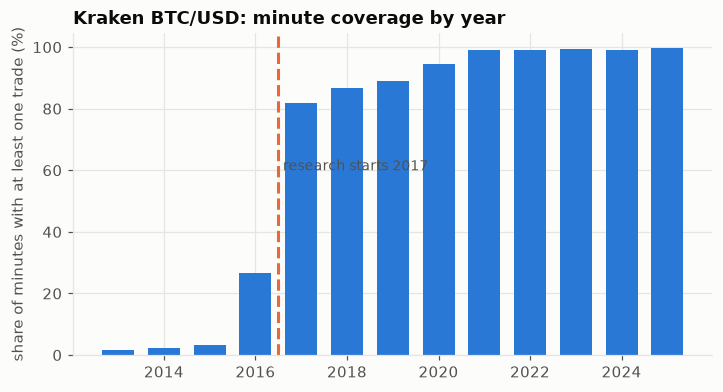

In [3]:
cov = (bars.with_columns(pl.col("ts").dt.year().alias("year"))
       .group_by("year").agg(pl.len().alias("bars")).sort("year")
       .with_columns((pl.col("bars") / (365 * 24 * 60) * 100).alias("pct")).to_pandas())
fig, ax = plt.subplots()
ax.bar(cov["year"], cov["pct"], color=st.BLUE, width=0.7)
ax.axvline(2016.5, color=st.ORANGE, ls="--")
ax.annotate("research starts 2017", (2016.6, 60), color=st.INK_SOFT, fontsize=9)
ax.set_ylabel("share of minutes with at least one trade (%)"); ax.set_title("Kraken BTC/USD: minute coverage by year")
plt.show()

Before 2017 fewer than a third of minutes have a trade, so prices are stale and a "volatility"
would mostly measure how long the market sat idle. **The research window starts on 2017-01-01**, where coverage exceeds 80%.
Ethereum starts around 2018 and Solana around 2022 for the same reason.

## 5.2 Estimating volatility: many recipes, one target

Volatility is the size of the random steps. Each estimator uses a different slice of the data:

| Estimator | Uses | Idea |
|---|---|---|
| **Close-to-close** | closing prices only | standard deviation of returns; the textbook benchmark |
| **Parkinson** | each bar's high and low | the *range* of a bar reveals how far the price roamed: $\hat\sigma^2 = \overline{\ln(H/L)^2}/(4\ln 2)$ |
| **Garman–Klass** | range plus open-to-close | adds the drift-free open→close move for extra precision |
| **Rogers–Satchell** | range, open, close | stays unbiased when the price is trending |
| **Realised variance** | many short returns (5-minute) | add up squared tiny returns; converges to true variance as sampling gets finer |

The theory promises that range-based estimators are several times more **efficient**: they get the
same accuracy from far less data because the range captures the whole path. `tests/test_vol.py` verifies that by simulation. On real data:

In [4]:
g = grid.build_hourly_grid(bars, start="2017-01-01")
n_days = len(g) // 24
close_d = g.close[: n_days * 24].reshape(n_days, 24)[:, -1]
hi_d = g.high[: n_days * 24].reshape(n_days, 24).max(axis=1)
lo_d = g.low[: n_days * 24].reshape(n_days, 24).min(axis=1)
op_d = np.concatenate([[g.close[0]], close_d[:-1]])
rv_d = g.rv[: n_days * 24].reshape(n_days, 24).sum(axis=1)
dates = pd.date_range("2017-01-01", periods=n_days, freq="D")

def rolling_30d(fn):
    return pd.Series([fn(slice(i - 30, i)) for i in range(30, n_days)], index=dates[30:])

cc = rolling_30d(lambda s: vol.close_to_close(np.concatenate([[op_d[s][0]], close_d[s]]), 365))
pk = rolling_30d(lambda s: vol.parkinson(hi_d[s], lo_d[s], 365))
rv = rolling_30d(lambda s: np.sqrt(rv_d[s].mean() * 365))

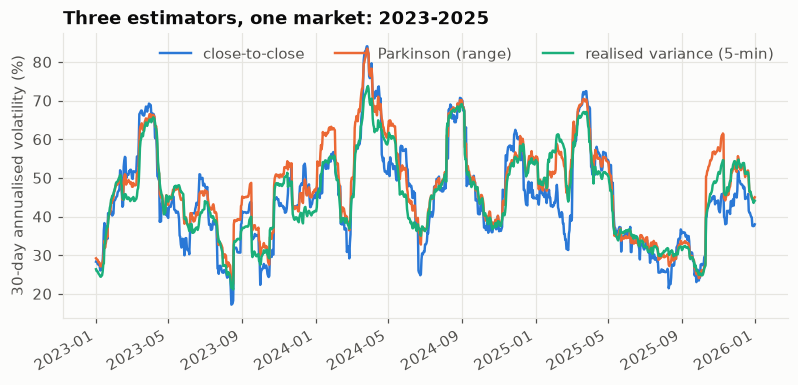

,mean vol (%),"week-to-week noise (std of weekly change, pts)"
close-to-close,44.67,6.69
Parkinson,47.44,5.88
realised variance,45.45,5.06


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
sel = slice("2023-01-01", "2025-12-31")
for series, name, colour in [(cc, "close-to-close", st.BLUE), (pk, "Parkinson (range)", st.ORANGE), (rv, "realised variance (5-min)", st.AQUA)]:
    ax.plot(series[sel].index, series[sel] * 100, color=colour, label=name, lw=1.6)
ax.set_ylabel("30-day annualised volatility (%)"); ax.set_title("Three estimators, one market: 2023-2025"); ax.legend(ncol=3, loc="upper right")
fig.autofmt_xdate(); plt.show()

table = pd.DataFrame({"mean vol (%)": [cc[sel].mean() * 100, pk[sel].mean() * 100, rv[sel].mean() * 100],
                      "week-to-week noise (std of weekly change, pts)": [cc[sel].diff(7).std() * 100, pk[sel].diff(7).std() * 100, rv[sel].diff(7).std() * 100]},
                     index=["close-to-close", "Parkinson", "realised variance"])
table.round(2)

All three track the same broad regime but the **range-based and realised-variance estimators are
smoother** for the same window length: they extract more information from each day (week-to-week
noise of 5.1 and 5.9 points versus 6.7 for close-to-close). The *levels* also differ by a few
points (about 45% versus 47% for Parkinson). In simulated Gaussian prices Parkinson reads slightly
*low*; on real Bitcoin it reads a little *high*, because real ranges include short spikes and
mean-reverting wicks that a smooth random walk would not produce. So there is no single "true"
volatility to recover: each estimator answers a slightly different question, and that gap is itself a
reminder to carry uncertainty about $\sigma$ forward (notebook 6).

## 5.3 Microstructure noise: the volatility signature plot

If prices were a perfect random walk, volatility measured from 1-minute returns and from 1-hour
returns would agree. In real markets tiny returns are contaminated by **bid-ask bounce** (the price
flipping between buyers' and sellers' quotes), so measured volatility *rises* as the sampling gets finer. The **signature plot** shows it: annualised volatility against sampling interval.

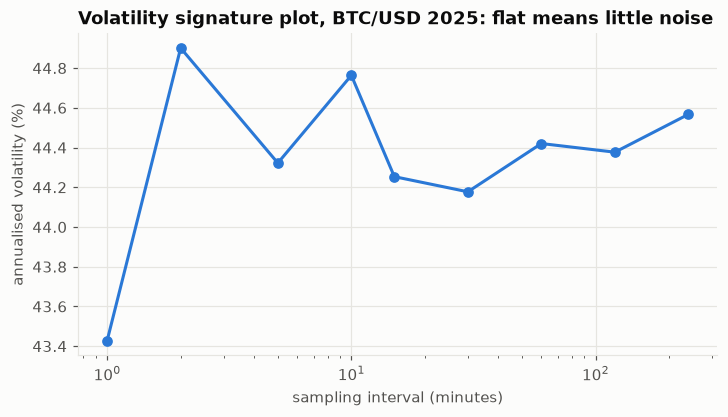

{1: 43.4, 2: 44.9, 5: 44.3, 10: 44.8, 15: 44.3, 30: 44.2, 60: 44.4, 120: 44.4, 240: 44.6}


In [6]:
recent = bars.filter(pl.col("ts") >= pl.datetime(2025, 1, 1, time_zone="UTC"))
dense = (pl.DataFrame({"ts": pl.datetime_range(recent["ts"].min(), recent["ts"].max(), "1m", time_zone="UTC", eager=True)})
         .join(recent.select("ts", "close"), on="ts", how="left").with_columns(pl.col("close").forward_fill()))
sig = vol.signature_plot(dense["close"].to_numpy(), (1, 2, 5, 10, 15, 30, 60, 120, 240))
fig, ax = plt.subplots()
ax.plot(list(sig), np.array(list(sig.values())) * 100, "o-", color=st.BLUE)
ax.set_xscale("log"); ax.set_xlabel("sampling interval (minutes)"); ax.set_ylabel("annualised volatility (%)")
ax.set_title("Volatility signature plot, BTC/USD 2025: flat means little noise")
plt.show()
print({k: round(v * 100, 1) for k, v in sig.items()})

For Bitcoin on Kraken the curve is nearly flat from 1 minute upward: the market is deep, bid-ask
bounce is tiny relative to price moves, and 1–5 minute sampling is safe. (Thinly traded coins and the
2013–2016 data would show a steep slope at the left, which is another reason we skip those years.) We use **5-minute returns** for realised variance.

## 5.4 Jumps: when one return dominates a day

Realised variance adds up *all* squared returns, so a single violent 5-minute move can dominate a
whole day's total. **Bipower variation** multiplies each return by its *neighbour's* size. A lone
jump is multiplied by an ordinary return, so it barely registers, while ordinary diffusion still counts. The gap
between the two is a measure of jumpiness:

$$\text{jump share} = \max\!\left(0,\ \frac{RV - BV}{RV}\right), \qquad BV = \tfrac{\pi}{2}\sum |r_i||r_{i-1}|.$$

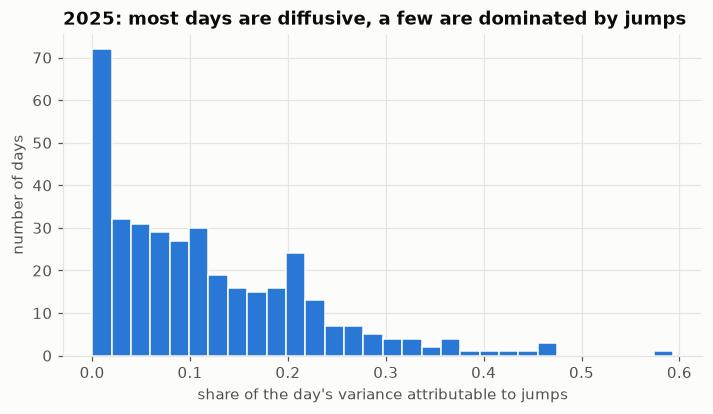

median jump share: 0.091 | days above 30%: 22 of 365


2025-07-10    0.59
2025-06-28    0.47
2025-10-26    0.47
2025-09-20    0.47
2025-09-06    0.44
dtype: float64

In [7]:
five = (recent.group_by_dynamic("ts", every="5m").agg(pl.col("close").last())
        .upsample("ts", every="5m").with_columns(pl.col("close").forward_fill()))
r5 = np.diff(np.log(five["close"].to_numpy()))
day = five["ts"].dt.date().to_numpy()[1:]
shares = pd.Series({d: vol.jump_share(r5[day == d]) for d in np.unique(day)})
fig, ax = plt.subplots()
ax.hist(shares.values, bins=30, color=st.BLUE, edgecolor=st.SURFACE)
ax.set_xlabel("share of the day's variance attributable to jumps"); ax.set_ylabel("number of days")
ax.set_title("2025: most days are diffusive, a few are dominated by jumps")
plt.show()
print("median jump share:", round(shares.median(), 3), "| days above 30%:", int((shares > 0.3).sum()), "of", len(shares))
shares.sort_values(ascending=False).head(5).round(2)

Most days have a small jump share, but a minority are jump-dominated. That matters for barrier
probabilities: **jumps create fat tails**, making far-out touches more likely than a plain Gaussian
model says. Notebook 7 models this explicitly.

## 5.5 Forecasting volatility: what predicts the next week?

Volatility clusters: calm follows calm, storms follow storms. Four ways to turn history into a forecast of the **average daily variance over the next 7 days**:

* **Trailing 30-day** realised variance: everything in the last month counts equally.
* **7-day**: more responsive but noisier.
* **EWMA**: recent days count more, with exponentially fading weights.
* **HAR-RV** (Corsi, 2009): a regression on yesterday's, last week's and last month's realised variance together, fitted **in logs**.

Fitted models are re-fitted each January using only earlier years, and everything is scored on 2022-2025 with **QLIKE**
($\overline{p/f - \ln(p/f) - 1}$, zero when perfect), the loss statisticians prefer for variance because it is not dominated by a few explosive days.

> **A lesson learnt the hard way.** The first version of this notebook fitted HAR on *raw* variances. The result was the *worst*
> forecast of the four: 2017-2018 had explosive variance days that dominated the regression, so the model over-forecast
> the calmer 2022-2025 period by about **2x**. Fitting in logs (where variance looks bell-shaped instead of wildly skewed) fixes it, and
> is what the code now does. Bugs of this kind are why every model is scored out-of-sample.

In [8]:
r_d = np.diff(np.log(close_d))                         # daily close-to-close returns, r_d[j] = day j+1
first_test = int((pd.Timestamp("2022-01-01") - dates[0]).days)
rows = {"trailing 30d": [], "7d": [], "EWMA (0.94)": [], "HAR-RV (log)": [], "target": []}
har, fitted_year = None, None
for t in range(first_test, n_days - 8):
    if har is None or dates[t].year != fitted_year:            # refit each January on the past only
        har, fitted_year = vol.HarRV(horizon_days=7).fit(rv_d[: t - 7]), dates[t].year
    rows["trailing 30d"].append(rv_d[t - 29 : t + 1].mean())
    rows["7d"].append(rv_d[t - 6 : t + 1].mean())
    rows["EWMA (0.94)"].append(vol.ewma_variance(r_d[max(0, t - 250) : t], 0.94))
    rows["HAR-RV (log)"].append(har.predict(rv_d[: t + 1]))
    rows["target"].append(rv_d[t + 1 : t + 8].mean())
res = pd.DataFrame(rows)
qlike = {k: vol.qlike(res["target"], res[k]) for k in res if k != "target"}
pd.DataFrame({"QLIKE (lower is better)": qlike, "average forecast / average outcome": {k: res[k].mean() / res["target"].mean() for k in qlike}}).sort_values("QLIKE (lower is better)").round(3)

,QLIKE (lower is better),average forecast / average outcome
HAR-RV (log),0.240,1.369
EWMA (0.94),0.275,0.985
trailing 30d,0.295,1.007
7d,0.320,1.003


**Log-HAR wins on QLIKE** (0.240, against 0.275 for EWMA, 0.295 for the trailing month and 0.320 for the 7-day), so it ranks
calm and stormy periods best. Notice the second column, though: on average it still forecasts about 37% **too high** in
2022-2025. Refitting each January only uses the past, and the past was more volatile, so the model is always a little
behind a market that has been calming down. Two consequences for pricing:

1. The choice of volatility input is not a detail. Gaps of this size become mispriced probabilities directly.
2. Even the best forecast is **wrong by a wide margin** over a week or a month, so a probability that treats the forecast as certain will be over-confident. Notebook 6 quantifies how wrong, and shows how to turn that honest uncertainty into better probabilities.

## Recap

* Bitcoin/USD has 92.7M trades; we distil them into 1-minute bars, the same granularity venues settle on.
* Coverage before 2017 is too thin to trust; the research window starts there.
* Range-based and realised-variance estimators are noticeably smoother than close-to-close; different estimators disagree by a few points, so there is no single true number.
* Bitcoin's signature plot is flat from 1 minute up, so 5-minute realised variance is safe.
* Jump-dominated days exist (about 6% of 2025 days had over 30% of their variance from jumps) and are studied in notebook 7.
* **Log-HAR-RV** is the best volatility forecaster tested out-of-sample; fitting it in levels was a mistake that only an out-of-sample test could reveal.